<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-4-projekt-grupowy-2/blob/main/2_Drzewo_Decyzyjne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Wczytanie bibliotek i zbiorów**

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, classification_report
from sklearn.model_selection import GridSearchCV

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# **Analiza modelu**

In [3]:
import numpy as np
from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    fbeta_score
)

def business_profit_score(y_true, y_pred):
    """
    Oblicza zysk biznesowy dla zadania.
    +1 za uratowane życie (True Positive - TP).
    -0.25 za utraconego pacjenta (False Positive - FP),
    ponieważ co czwarty fałszywy alarm pacjent odinstalowujący aplikację.
    """
    _, fp, _, tp = confusion_matrix(y_true, y_pred).ravel()

    return tp - (0.25 * fp)

# Tworzymy obiekt scorer gotowy do użycia
custom_business_scorer = make_scorer(business_profit_score, greater_is_better=True)

# Tworzymy osobną metrykę F2 do śledzenia (Czułość jest dla nas 2x ważniejsza)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Słownik wszystkich metryk do wykorzystania w GridSearchCV (parametr: scoring=scoring_dict)
scoring_dict = {
    'Business_Score': custom_business_scorer,
    'F2_Score': f2_scorer,
    'ROC_AUC': 'roc_auc',
    'PR_AUC': 'average_precision'
}


def evaluate_heart_model(model, X_test, y_test):
    """
    Wypisuje pełny raport skuteczności modelu przetestowanego na zbiorze testowym.
    """
    y_pred = model.predict(X_test)

    # Pobieramy prawdopodobieństwa (potrzebne do ROC i PR AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback np. dla dec_function
        y_proba = model.decision_function(X_test)

    print("--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---")
    print(f"Zysk Biznesowy (TP - 0.25*FP): {business_profit_score(y_test, y_pred):.2f}")
    print(f"F2-Score (Nacisk na Czułość):  {fbeta_score(y_test, y_pred, beta=2):.4f}")
    print(f"ROC AUC:                       {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR AUC (Average Precision):    {average_precision_score(y_test, y_proba):.4f}")
    print("\n--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---")
    print(classification_report(y_test, y_pred))

# **Model bazowy (bez optymalizacji hiperparametrów)**

In [4]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

evaluate_heart_model(tree, X_test, y_test)

--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---
Zysk Biznesowy (TP - 0.25*FP): -6.50
F2-Score (Nacisk na Czułość):  0.1172
ROC AUC:                       0.5343
PR AUC (Average Precision):    0.0559

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       972
           1       0.11      0.12      0.11        50

    accuracy                           0.91      1022
   macro avg       0.53      0.53      0.53      1022
weighted avg       0.91      0.91      0.91      1022



# **Badania hiperparametrów i trening najlepszego modelu**

In [5]:
# Wartości do zbadania
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': [
        'balanced',
        {0: 1, 1: 5},
        {0: 1, 1: 10}
    ]
}

base_tree = DecisionTreeClassifier(random_state=42)

# Optymalizujemy pod zysk biznesowy
grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='Business_Score',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

print("\nNajlepsze znalezione parametry:")
print(grid_search.best_params_)
print("-" * 50)


"""Ocena ostateczna"""
evaluate_heart_model(best_tree, X_test, y_test)


Najlepsze znalezione parametry:
{'class_weight': {0: 1, 1: 5}, 'max_depth': 3, 'min_samples_leaf': 10}
--------------------------------------------------
--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---
Zysk Biznesowy (TP - 0.25*FP): 3.00
F2-Score (Nacisk na Czułość):  0.4519
ROC AUC:                       0.8071
PR AUC (Average Precision):    0.1839

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       972
           1       0.22      0.62      0.32        50

    accuracy                           0.87      1022
   macro avg       0.60      0.75      0.63      1022
weighted avg       0.94      0.87      0.90      1022



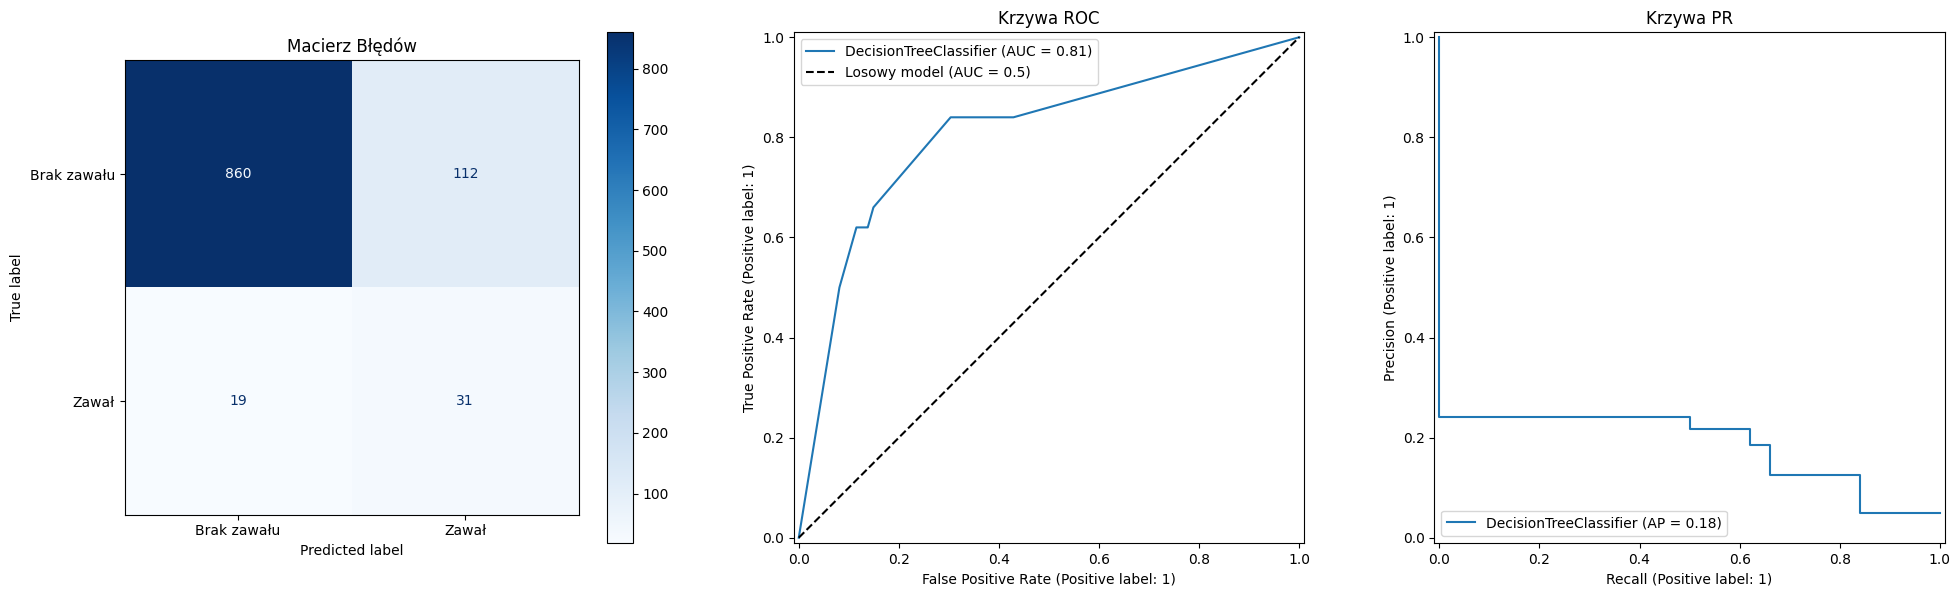

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ConfusionMatrixDisplay.from_estimator(
    best_tree, X_test, y_test,
    display_labels=['Brak zawału', 'Zawał'],
    cmap='Blues', ax=ax1
)
ax1.set_title("Macierz Błędów")


RocCurveDisplay.from_estimator(best_tree, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], 'k--', label='Losowy model (AUC = 0.5)')
ax2.set_title("Krzywa ROC")
ax2.legend()

PrecisionRecallDisplay.from_estimator(best_tree, X_test, y_test, ax=ax3)
ax3.set_title("Krzywa PR")

plt.tight_layout()
plt.show()

# **Wizualizacja drzewa**

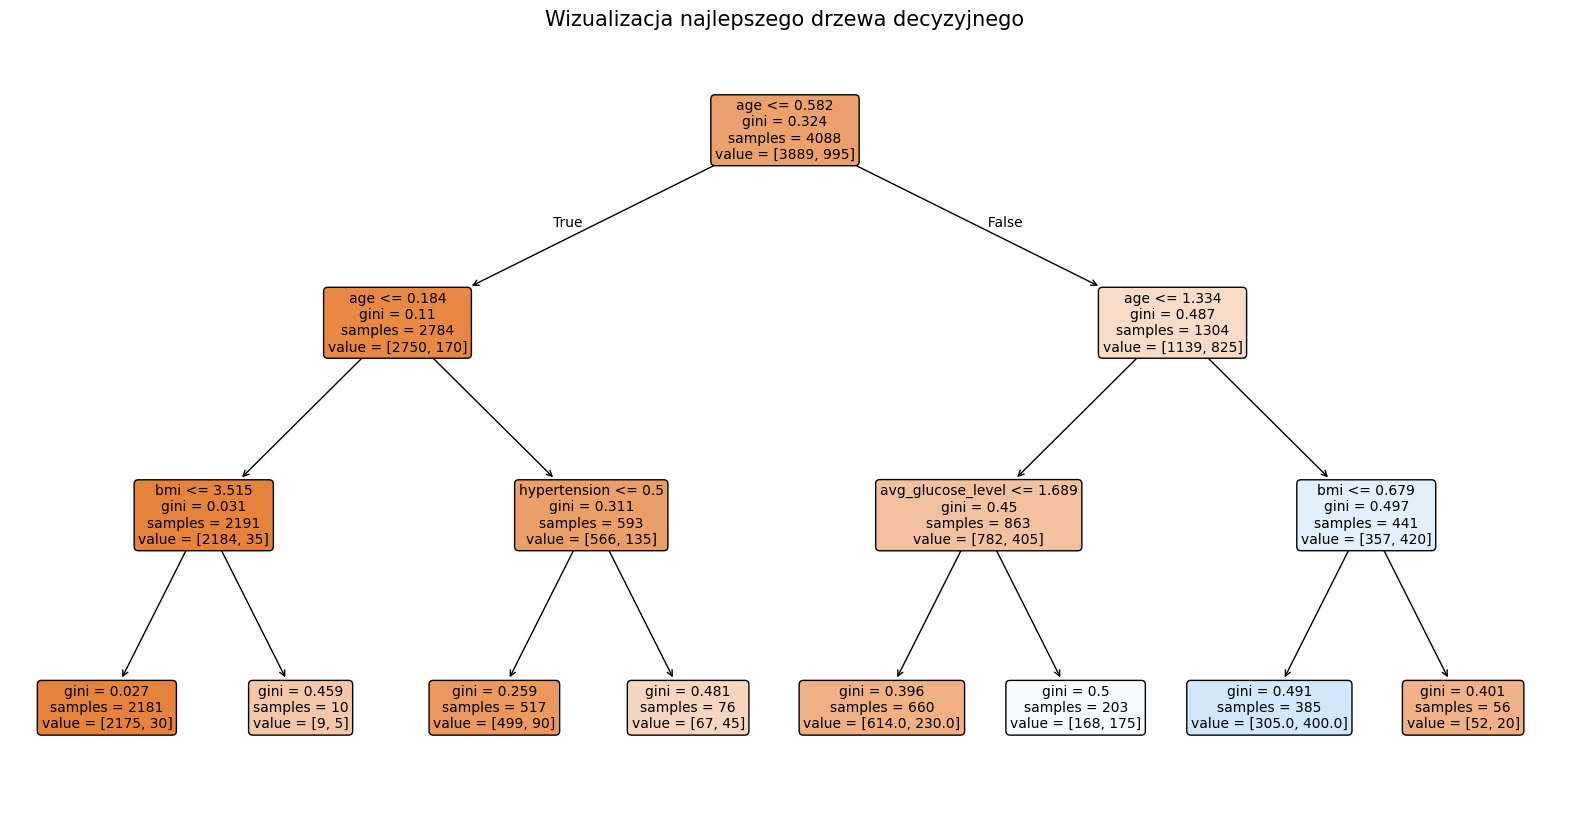

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)

plt.title("Wizualizacja najlepszego drzewa decyzyjnego", fontsize=15)
plt.show()

# **Wykresy: Accuracy i Recall**

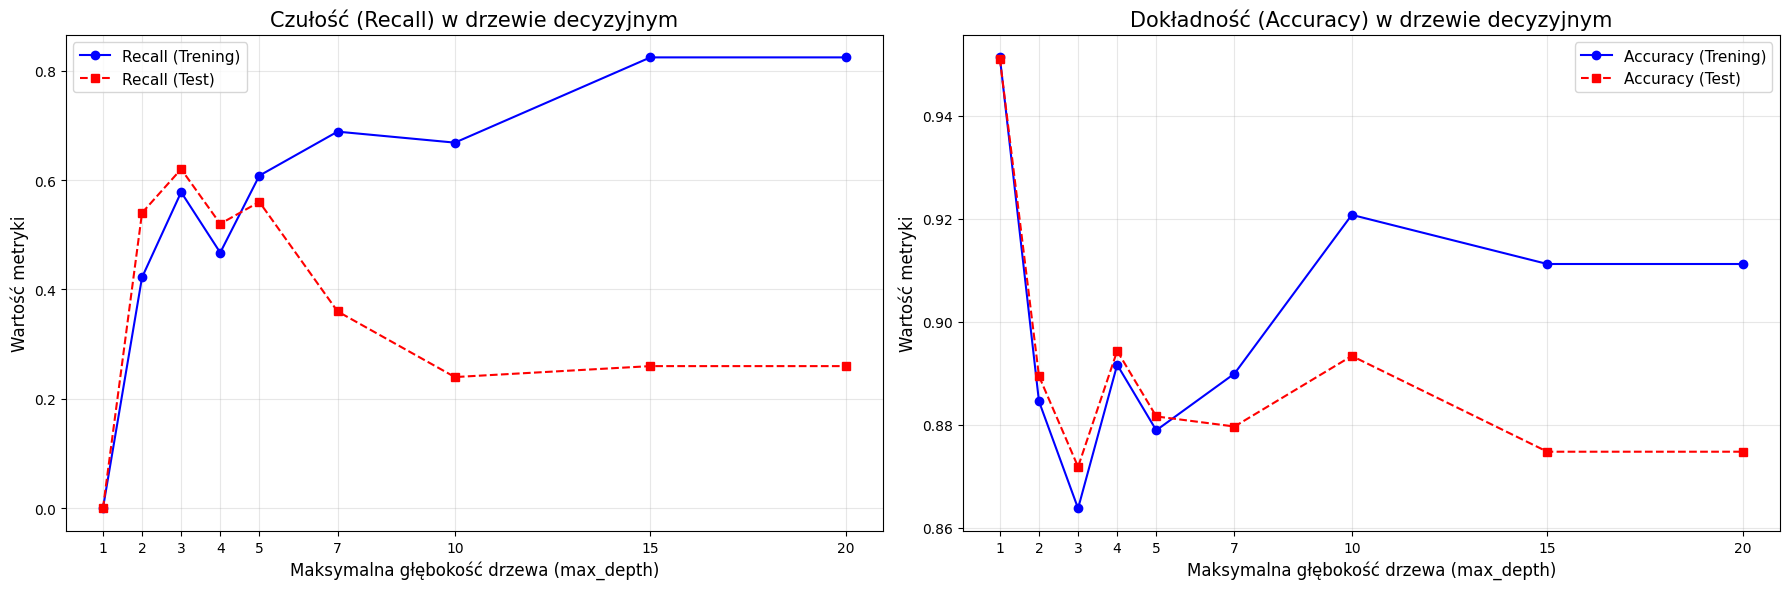

In [8]:
test_depths = [1, 2, 3, 4, 5, 7, 10, 15, 20]

train_recalls, test_recalls = [], []
train_accuracies, test_accuracies = [], []

for depth in test_depths:
    params = grid_search.best_params_.copy()
    if 'max_depth' in params:
      del params['max_depth']

    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42, **params)
    temp_model.fit(X_train, y_train)

    y_train_pred = temp_model.predict(X_train)
    y_test_pred = temp_model.predict(X_test)

    train_recalls.append(recall_score(y_train, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(test_depths, train_recalls, label='Recall (Trening)', marker='o', color='blue')
ax1.plot(test_depths, test_recalls, label='Recall (Test)', marker='s', linestyle='--', color='red')
ax1.set_title('Czułość (Recall) w drzewie decyzyjnym', fontsize=15)
ax1.set_xlabel('Maksymalna głębokość drzewa (max_depth)', fontsize=12)
ax1.set_ylabel('Wartość metryki', fontsize=12)
ax1.set_xticks(test_depths)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(test_depths, train_accuracies, label='Accuracy (Trening)', marker='o', color='blue')
ax2.plot(test_depths, test_accuracies, label='Accuracy (Test)', marker='s', linestyle='--', color='red')
ax2.set_title('Dokładność (Accuracy) w drzewie decyzyjnym', fontsize=15)
ax2.set_xlabel('Maksymalna głębokość drzewa (max_depth)', fontsize=12)
ax2.set_ylabel('Wartość metryki', fontsize=12)
ax2.set_xticks(test_depths)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()